In [1]:
from importlib.metadata import version
print("langchain version: ", version("langchain"))
print("langgraph version: ", version("langgraph"))
print("langchain-openai version: ", version("langchain-openai"))
print("langchain-core version: ", version("langchain-core"))
print("langchain_community version: ", version("langchain_community"))
print("langchain_mcp_adapters version: ", version("langchain_mcp_adapters"))
print("tavily-python version: ", version("tavily-python"))

langchain version:  1.3.14
langgraph version:  1.2.9
langchain-openai version:  1.4.1
langchain-core version:  1.5.1
langchain_community version:  0.4.2
langchain_mcp_adapters version:  0.3.0
tavily-python version:  0.7.26


In [2]:
import os
from dotenv import load_dotenv
import openai
load_dotenv()

False

2026-07-28 19:04:49 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'draft' with handle 'deepseek-v4-flash' (timeout=600)
2026-07-28 19:04:50 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'researcher_summarizer' with handle 'deepseek-v4-flash' (timeout=600)
2026-07-28 19:04:50 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'writer' with handle 'deepseek-v4-flash' (timeout=600)
2026-07-28 19:04:50 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'researcher_main' with handle 'deepseek-v4-flash' (timeout=600)
2026-07-28 19:04:50 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'researcher_compressor' with handle 'deepseek-v4-flash' (timeout=600)
2026-07-28 19:04:50 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'red_team' with handle 'deepseek-v4-flash' (timeout=600)
2026-07-28 19:04:50 [INFO] deep_research.llm: Selected cognition backend 'openai' fo

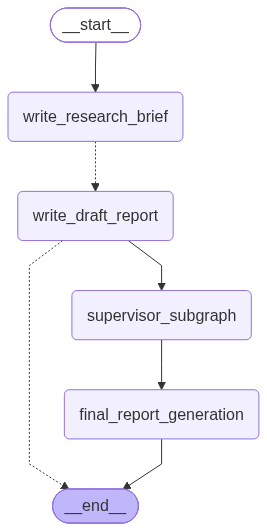

In [3]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from deep_research.agent_builder import deep_researcher_builder
import warnings

warnings.filterwarnings("ignore")
checkpointer = InMemorySaver()
full_agent = deep_researcher_builder.compile(checkpointer=checkpointer)
display(Image(full_agent.get_graph(xray=True).draw_mermaid_png()))

In [4]:
from openai import OpenAI
from deep_research.utils import load_config

cfg = load_config("prod", "config.yml")

client = OpenAI(
    api_key=cfg["cognition"]["openai"]["api_key"],
    base_url=cfg["cognition"]["openai"]["base_url"],
)

response = client.chat.completions.create(
    model="deepseek-v4-flash",
    messages=[
        {
            "role":"user",
            "content":"Hello"
        }
    ]
)

print(response.choices[0].message.content)
print(response.usage)

你好！😊 很高兴见到你。我是 DeepSeek，随时准备为你提供帮助。有什么想问的，或者需要我帮忙的吗？无论是聊天、解答问题，还是处理文件、分析信息，我都在这里！
CompletionUsage(completion_tokens=144, prompt_tokens=5, total_tokens=149, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=None, reasoning_tokens=96, rejected_prediction_tokens=None), prompt_tokens_details=PromptTokensDetails(audio_tokens=None, cache_write_tokens=None, cached_tokens=0), prompt_cache_hit_tokens=0, prompt_cache_miss_tokens=5)


In [ ]:
# take 10 ~ 20 minutes to finish the task.
from langchain_core.messages import HumanMessage
thread = {
    "configurable": {
        "thread_id": "memory-research-1"
    },
    "recursion_limit": 50
}
result = await full_agent.ainvoke({"messages": [HumanMessage(content="我是个 AI 产品经理，正在考虑给产品增加个性化记忆功能。想系统了解一下现在 Agent 里的 Memory 模块都在往哪些方向发展，包括短期和长期记忆是怎么做的、各种技术路线的差异和取舍。你帮我写个调研报告，从工程落地和未来演进的角度分析一下 哪些方向更值得投入")]}, config=thread)

2026-07-28 19:05:04 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor invoked (iteration=0, messages=2)
2026-07-28 19:05:08 [INFO] deep_research.agents.supervisor: supervisor model produced tool_calls=True num_tool_calls=1
2026-07-28 19:05:08 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor_tools executing think=1 conduct=0 refine=0
2026-07-28 19:05:08 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor invoked (iteration=1, messages=4)
2026-07-28 19:05:23 [INFO] deep_research.agents.supervisor: supervisor model produced tool_calls=True num_tool_calls=3
2026-07-28 19:05:23 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor_tools executing think=0 conduct=3 refine=0
2026-07-28 19:05:25 [INFO] deep_research.agents.research_agent: llm_call produced response tool_calls=True num_tool_calls=3
2026-07-28 19:05:25 [INFO] deep_research.agents.research_agent: should_continue decision=tool_node (has_tool_calls=True)
2026-07-28 19:05:25 [INFO] 

2026-07-28 19:05:27 [ERROR] deep_research.tools.tool: Failed to summarize webpage: Error code: 400 - {'error': {'message': 'This response_format type is unavailable now', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}


2026-07-28 19:05:27 [INFO] deep_research.agents.research_agent: Invoking tool tavily_search with args={'query': 'Claude Anthropic memory long context window Projects feature 2024 2025'}


2026-07-28 19:05:28 [ERROR] deep_research.tools.tool: Failed to summarize webpage: Error code: 400 - {'error': {'message': 'This response_format type is unavailable now', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}


2026-07-28 19:05:28 [INFO] deep_research.agents.research_agent: Invoking tool tavily_search with args={'query': 'AI agent long-term memory vector database implementation Pinecone Weaviate Chroma embedding strategies 2024'}


...

2026-07-28 19:06:04 [INFO] deep_research.agents.research_agent: llm_call produced response tool_calls=True num_tool_calls=1
2026-07-28 19:06:04 [INFO] deep_research.agents.research_agent: should_continue decision=tool_node (has_tool_calls=True)
2026-07-28 19:06:04 [INFO] deep_research.agents.research_agent: tool_node executing 1 tool calls
2026-07-28 19:06:04 [INFO] deep_research.agents.research_agent: Invoking tool think_tool with args={'reflection': 'I now have comprehensive information across all 7 areas. Let me compile the full research report with specific technical details, references, and implementation considerations.'}
2026-07-28 19:06:05 [INFO] deep_research.agents.research_agent: llm_call produced response tool_calls=True num_tool_calls=1
2026-07-28 19:06:05 [INFO] deep_research.agents.research_agent: should_continue decision=tool_node (has_tool_calls=True)
2026-07-28 19:06:05 [INFO] deep_research.agents.research_agent: tool_node executing 1 tool calls
2026-07-28 19:06:05 [I

2026-07-28 19:06:08 [ERROR] deep_research.tools.tool: Failed to summarize webpage: Error code: 400 - {'error': {'message': 'This response_format type is unavailable now', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}


2026-07-28 19:06:08 [INFO] deep_research.agents.research_agent: Invoking tool tavily_search with args={'query': 'AI memory management interface UX design memory visualization editing deletion patterns'}


2026-07-28 19:06:11 [ERROR] deep_research.tools.tool: Failed to summarize webpage: Error code: 400 - {'error': {'message': 'This response_format type is unavailable now', 'type': 'invalid_request_error', 'param': None, 'code': 'invalid_request_error'}}


2026-07-28 19:06:14 [INFO] deep_research.agents.research_agent: llm_call produced response tool_calls=True num_tool_calls=1
2026-07-28 19:06:14 [INFO] deep_research.agents.research_agent: should_continue decision=tool_node (has_tool_calls=True)
2026-07-28 19:06:14 [INFO] deep_research.agents.research_agent: tool_node executing 1 tool calls
2026-07-28 19:06:14 [INFO] deep_research.agents.research_agent: Invoking tool think_tool with args={'reflection': 'Excellent! I now have comprehensive information across all the requested areas. Let me compile the full research report. I have:\n\n1. **ChatGPT/OpenAI**: Memory feature details, privacy controls, GPTs knowledge retrieval, technical architecture\n2. **Claude/Anthropic**: Long context window, Projects feature, knowledge base, Artifacts\n3. **Microsoft Copilot**: Graph-based memory, enterprise compliance, M365 integration\n4. **Other AI Assistants**: Google Gemini context window, Perplexity AI, Character.AI, Replika, open-source projects (

In [6]:
from rich.console import Console
from rich.markdown import Markdown

# 创建控制台对象
console = Console()
console.print(Markdown(result["final_report"]))

AI Agent 记忆模块（Memory Module）深度调研报告                                   

1. 引言与背景                                                                                                      

随着大语言模型（LLM）从单纯的对话工具向自主智能体（AI                                                              
Agent）演进，记忆模块已成为决定智能体能力上限的核心基础设施。当前主流AI产品（如ChatGPT、Claude、Copilot）均已开始探
索不同形态的记忆功能，但技术路线、工程实现和产品形态差异显著。本报告基于对短期/长期记忆技术、行业实践案例、未来演进
方向的系统性调研，旨在为AI产品经理提供一份从技术原理到工程落地的完整决策参考。                                     

记忆模块的核心挑战在于：如何在有限的计算资源和成本约束下，让AI                                                     
Agent能够跨会话、跨任务地保持对用户偏好、历史交互和领域知识的持续理解。这涉及上下文窗口管理、向量检索、知识图谱、模
型微调等多个技术栈的协同工作。本报告将逐一剖析这些技术路线，并结合行业领先产品的实践经验，给出可操作的优先级建议。 

-------------------------------------------------------------------------------------------------------------------

2. 短期记忆与长期记忆的技术实现                                                                                    

2.1 短期记忆技术                                                                                                   

短期记忆的核心目标是管理LLM的上下文窗口，确保当前交互的连贯性和响应质量。其技术实现主要围绕上下文窗口管理、缓存机制
和Token预算控制三个维度展开。                                                                                      

上下文窗口管理方面，滑动窗口（Sliding                                                                              
Window）是最基础的实现方式——维护一个固定大小的Token缓冲区，新Token到达时淘汰最旧的Token。这种机制简单高效，但会牺牲
长距离依赖关系。更精细的Token预算管理（Token                                                                       
Budgeting）则根据内容优先级分配上下文空间：系统提示、用户指令和最近交互获得最高优先级，而冗长的日志或较旧的对话轮次
则被优先压缩或淘汰。LangChain的ConversationSummaryBufferMemory正是采用这种策略——在Token预算耗尽时，将原始对话替换为
LLM生成的摘要。                                                                                                    

缓存机制是短期记忆优化的另一关键领域。KV-Cache（Key-Value                                                          
Cache）是自回归LLM推理的基础优化——每个Transformer层为已生成的Token计算Key和Value矩阵并缓存，避免重复计算。然而，KV-
Cache的内存占用随序列长度线性增长：以LLaMA-70B为例，4K上下文在FP16精度下需要约40GB显存。为此，业界发展出多项优化技 
术：vLLM的PagedAttention通过非连续内存块管理KV-Cache，将碎片化减少96%并实现2-4倍的吞吐量提升；多查询注意力（MQA）和
分组查询注意力（GQA）通过共享KV对将缓存大小减少80%；KV-Cache量化（如KIVI、KVQuant）则通过INT8/FP8精度进一步压缩。  

语义缓存（Semantic                                                                                                 
Caching）是另一重要方向——将用户查询嵌入后与缓存查询的嵌入进行余弦相似度比较，当相似度超过阈值（如0.92）时直接返回缓
存响应。这种方法可将API调用减少30-60%，尤其适用于重复性查询模式。提示缓存（Prompt                                  
Caching）则缓存系统提示和对话公共前缀的KV-Cache状态，Anthropic报告称可节省高达90%的重复内容成本。                  

Token限制策略方面，不同模型的实际有效上下文长度与广告值存在显著差异。Gemini 1.5 Pro/2.0以1M-2M                     
Token的上下文窗口领先，有效性能约800K-1.5M Token；Claude 3.5 Sonnet/4提供200K-1M Token，有效约150K-700K；GPT-4     
Turbo/4o的128K Token窗口有效约80K-100K。Liu等人（2023）发现的“中间迷失”（Lost in the                               
Middle）问题表明，LLM在长上下文中的信息检索呈现U形性能曲线——开头和结尾的信息检索准确率约75%，而中间部分降至55-60%。
缓解策略包括按相关性重新排序文档（最相关的内容放在开头和结尾）、使用结构化上下文格式以及多步检索。                 

近期技术进展正在突破这些限制：FlashAttention-3在H100 GPU上达到1.3 PFLOPs/s的吞吐量；Ring                           
Attention通过分布式计算支持超过1亿Token的序列；测试时训练（TTT-E2E）实现了2M上下文35倍的速度提升[1]。              

2.2 长期记忆技术                                                                                                   

长期记忆的目标是让AI                                                                                               
Agent跨会话、跨任务地保持对用户和领域的持久理解。当前主流技术路线包括向量数据库、知识图谱、结构化数据库和模型微调，
实际生产系统通常采用混合架构。                                                                                     

向量数据库通过存储文本嵌入（dense                                                                                  
vector）并支持语义相似度搜索，是实现长期记忆最广泛采用的技术。主流方案包括Pinecone（全托管云服务，HNSW索引，P99延迟
约10ms）、Weaviate（支持自托管+云，提供BM25+向量的混合搜索）、Chroma（嵌入式轻量级方案，Python原生，延迟1-5ms）、Qd
rant（内置BM25+向量融合，P99延迟5-10ms）和Milvus（支持IVF、HNSW、DiskANN等多种索引，适合大规模部署）。嵌入策略的选 
择直接影响检索精度：文档级嵌入适合粗粒度检索，分块级嵌入（256-512                                                  
Token，带重叠）提供更高精度，分层嵌入则同时存储粗粒度和细粒度表示。主流嵌入模型包括OpenAI                          
text-embedding-3-large（3072维）、Cohere                                                        

In [7]:
from datetime import date
path = f"./output_report_{date.today().strftime("%Y-%m-%d")}.md"
with open(path, "w") as fd:
    fd.write(result["final_report"])
print(f"调研报告已保存在{path}.")

调研报告已保存在./output_report_2026-07-28.md.


In [8]:
print(result["final_report"])

# AI Agent 记忆模块（Memory Module）深度调研报告

## 1. 引言与背景

随着大语言模型（LLM）从单纯的对话工具向自主智能体（AI Agent）演进，记忆模块已成为决定智能体能力上限的核心基础设施。当前主流AI产品（如ChatGPT、Claude、Copilot）均已开始探索不同形态的记忆功能，但技术路线、工程实现和产品形态差异显著。本报告基于对短期/长期记忆技术、行业实践案例、未来演进方向的系统性调研，旨在为AI产品经理提供一份从技术原理到工程落地的完整决策参考。

记忆模块的核心挑战在于：如何在有限的计算资源和成本约束下，让AI Agent能够跨会话、跨任务地保持对用户偏好、历史交互和领域知识的持续理解。这涉及上下文窗口管理、向量检索、知识图谱、模型微调等多个技术栈的协同工作。本报告将逐一剖析这些技术路线，并结合行业领先产品的实践经验，给出可操作的优先级建议。

---

## 2. 短期记忆与长期记忆的技术实现

### 2.1 短期记忆技术

短期记忆的核心目标是管理LLM的上下文窗口，确保当前交互的连贯性和响应质量。其技术实现主要围绕上下文窗口管理、缓存机制和Token预算控制三个维度展开。

**上下文窗口管理**方面，滑动窗口（Sliding Window）是最基础的实现方式——维护一个固定大小的Token缓冲区，新Token到达时淘汰最旧的Token。这种机制简单高效，但会牺牲长距离依赖关系。更精细的Token预算管理（Token Budgeting）则根据内容优先级分配上下文空间：系统提示、用户指令和最近交互获得最高优先级，而冗长的日志或较旧的对话轮次则被优先压缩或淘汰。LangChain的`ConversationSummaryBufferMemory`正是采用这种策略——在Token预算耗尽时，将原始对话替换为LLM生成的摘要。

**缓存机制**是短期记忆优化的另一关键领域。KV-Cache（Key-Value Cache）是自回归LLM推理的基础优化——每个Transformer层为已生成的Token计算Key和Value矩阵并缓存，避免重复计算。然而，KV-Cache的内存占用随序列长度线性增长：以LLaMA-70B为例，4K上下文在FP16精度下需要约40GB显存。为此，业界发展出多项优化技术：vLLM的P

In [9]:
from pathlib import Path
from datetime import datetime

output_path = Path("results") / f"memory_research_{datetime.now():%Y%m%d_%H%M%S}.md"
output_path.parent.mkdir(parents=True, exist_ok=True)

output_path.write_text(
    result["final_report"],
    encoding="utf-8"
)

print(f"Saved to: {output_path.resolve()}")

Saved to: C:\Users\铭\Desktop\Research\project-Deep_Research\results\memory_research_20260728_191243.md
